# Autonomous Driving Technologies Data Analysis Report

## Contents

## Introduction

## Methodology

## Data Analysis

### Loading Data

In [1]:
%matplotlib inline
import sys
sys.path.append('.')

from visibility_inspect import inspect_visibility
from analyze_visibility import analyze_visibility
from plot_metrics import plot_metrics

DATAROOT = './data/man-truckscenes'
VERSION = 'v1.2-mini'

### Inspecting Data

In [2]:
inspection = inspect_visibility(DATAROOT, version=VERSION)
inspection

Loading dataset metadata...
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

=== Available Sensor Channels ===
- RADAR_RIGHT_BACK
- RADAR_RIGHT_SIDE
- RADAR_RIGHT_FRONT
- RADAR_LEFT_FRONT
- RADAR_LEFT_SIDE
- RADAR_LEFT_BACK
- LIDAR_LEFT
- LIDAR_RIGHT
- LIDAR_TOP_FRONT
- LIDAR_TOP_LEFT
- LIDAR_TOP_RIGHT
- LIDAR_REAR
- CAMERA_LEFT_FRONT
- CAMERA_LEFT_BACK
- CAMERA_RIGHT_FRONT
- CAMERA_RIGHT_BACK

Selected Test Channels: Camera [CAMERA_LEFT_FRONT], LiDAR [LIDAR_LEFT]
Camera Mean Brightness (0=Dark, 255=Bright): 113.52
LiDAR Total Return Points: 79594


{'cam_channel': 'CAMERA_LEFT_FRONT',
 'lidar_channel': 'LIDAR_LEFT',
 'brightness': 113.51520775089173,
 'lidar_points': 79594}

### Visibility

In [3]:
df = analyze_visibility(DATAROOT, version=VERSION, output_csv='visibility_sensor_metrics.csv')
df.head()

Processing scenes and computing sensor metrics across visibility conditions...

  SENSOR METRICS COMPARISON ACROSS VISIBILITY CONDITIONS
          Camera_Brightness        LiDAR_Points          Radar_Points        
                       mean    std         mean      std         mean     std
Condition                                                                    
Clear                102.02  33.17     17981.42  1428.83       574.48  140.58
Rainy                104.40   2.35     16299.41  1454.76       345.70  186.69
Snowy                108.14   2.71     10133.05  1974.73       315.62   79.08

Extracted dataset successfully saved to: visibility_sensor_metrics.csv


,Scene,Condition,Camera_Brightness,LiDAR_Points,Radar_Points
0,scene-0044384af3d8494e913fb8b14915239e-3,Clear,113.515208,17180,800
1,scene-0044384af3d8494e913fb8b14915239e-3,Clear,113.306229,17323,800
2,scene-0044384af3d8494e913fb8b14915239e-3,Clear,113.020065,17760,800
3,scene-0044384af3d8494e913fb8b14915239e-3,Clear,115.320944,17718,800
4,scene-0044384af3d8494e913fb8b14915239e-3,Clear,114.139740,17834,800


Academic figure successfully generated and saved to: sensor_degradation_comparison.png


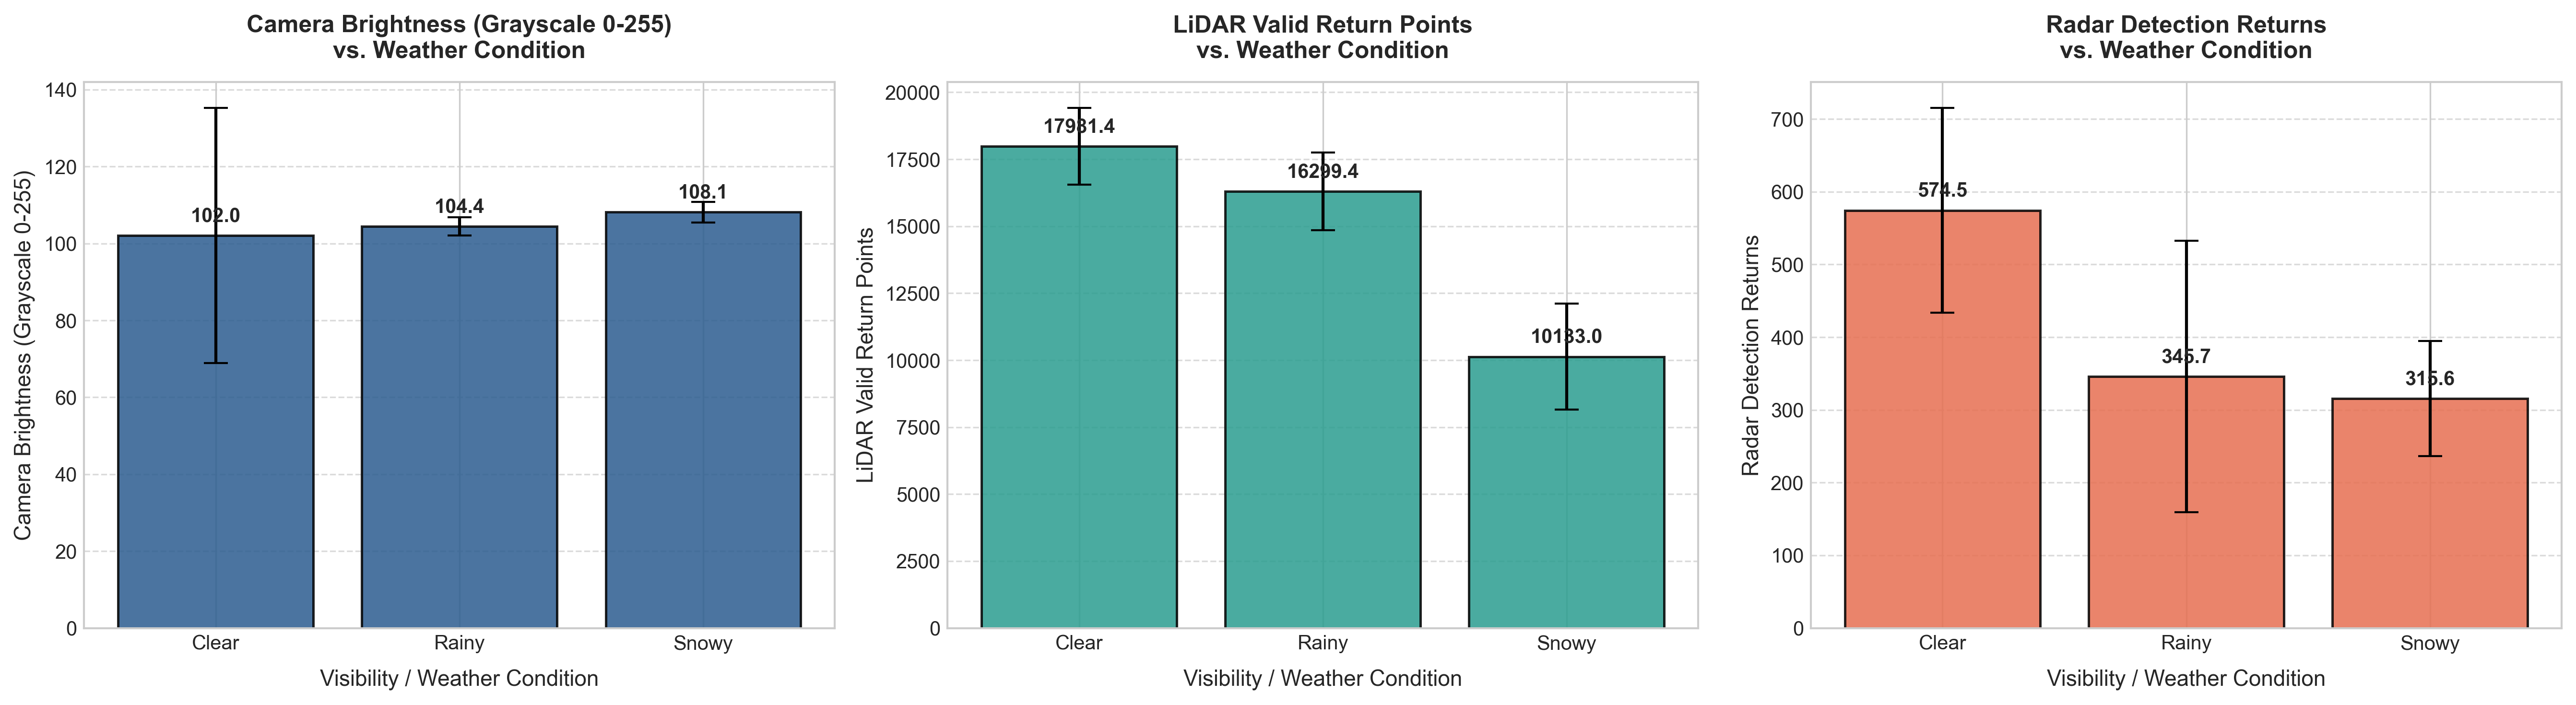

In [4]:
fig = plot_metrics(df, output_fig='sensor_degradation_comparison.png')

### Different Areas

#### Hypothesis
This section outlines the analysis regarding "different areas." During data collection, various factors can influence the ease or difficulty of detecting objects within a specific area. The dataset includes several conditions affecting sensor readings, one of which is the Area. Three distinct area types are recorded in the dataset: Terminal, Highway, and City. Before processing the data, I formulated an initial hypothesis to test: "Does the type of area where the truck operates affect the ease with which RADAR and LiDAR detect surrounding objects?" Logically, in an area cluttered with buildings, other vehicles, or structures that obstruct the view, sensors might struggle to detect objects. Conversely, in more open areas like highways, detection is expected to be easier due to the scarcity of obstructions. This is a hypothesis to be tested, not an assumed conclusion.

#### What are we looking for?
The goal of the analysis is to determine whether the data supports the aforementioned hypothesis. We aim to calculate three key metrics, all of which are restricted to scenes with clear weather conditions. This restriction is crucial to avoid misinterpretation; for instance, a scene showing poor detection might be attributed to the area itself when, in reality, the issue was caused by rain during recording. Limiting the scope in this way minimizes the impact of extraneous variables on the results.

The three key metrics are:
- The number of points (point count) captured by RADAR and LiDAR in each scene, grouped by area.
- The detection range of RADAR and LiDAR in each area—specifically, how far the sensors can effectively "see."
- The percentage of objects that failed to be detected by RADAR entirely (resulting in zero RADAR points) in each area.

#### Findings
Before presenting the numbers, it's worth noting that the truck used to collect this dataset is not equipped with a single RADAR and a single LiDAR. It carries multiple sensors of each type, mounted at different points around the vehicle (front, left, right, and so on). The point counts and ranges reported below are aggregated across all of these sensors per scene, not from one sensor alone.

In [5]:
from analyze_areas import analyze_areas

clear_scenes_full, zero_radar_summary = analyze_areas(DATAROOT, version=VERSION, output_csv='different_areas_metrics')

Parsing scene tags and filtering to clear-weather scenes...
Found 4 clear-weather scenes. Computing point count and range metrics...
Computing per-area zero-RADAR-detection rates...

  DIFFERENT AREAS: POINT COUNT & RANGE (clear weather)
                               scene_name     area  lidar_total_points  lidar_median_range  lidar_p95_range  radar_total_points  radar_max_range  radar_median_range  radar_p95_range
 scene-0044384af3d8494e913fb8b14915239e-3 terminal           9847737.0           10.468001        49.643997            164313.0       189.524134           75.655420       167.007624
 scene-13f4b71b1bd04a9e88747ad8f58a3f67-4  highway           9515612.0           16.035998        85.611997            132792.0       189.524069           71.784349       161.963088
scene-a6a87db5125846bda72ccfc9931ee153-11     city          10328874.0           12.491999        61.607999            104876.0       189.523163           61.975716       151.913938
scene-fb64d203d417452f830ca73efed8

**Point Count and Range per Area (clear weather only)**

One pattern stands out immediately: the RADAR max range is nearly identical (~189.5 m) across every scene, regardless of area type. This is very unlikely to reflect anything about the environment. It's far more likely to be the hardware's built-in maximum detection ceiling, the same way a car's speedometer stops at a fixed number regardless of road conditions. Because this value doesn't vary with area, it can't tell us anything about which areas are easier or harder to detect in. For that reason, the median and P95 (95th percentile) range are used instead: the median reflects the "typical" distance at which points are actually captured, and P95 captures the range within which the vast majority (95%) of points fall — both are a more honest picture of the sensor's effective, everyday reach in a given area than the theoretical maximum.

**Percentage of Objects with Zero RADAR Points, per Area**

This metric is not a percentage of total RADAR points — it's the share of individual objects (cars, trucks, pedestrians, etc.) that RADAR failed to register even a single point on. In the Highway area, for example, 59.8% of the 1,289 recorded objects (roughly 771 objects) produced zero RADAR points at all — meaning RADAR was effectively "blind" to more than half the objects present.



Figure saved to: different_areas_radar_metrics.png


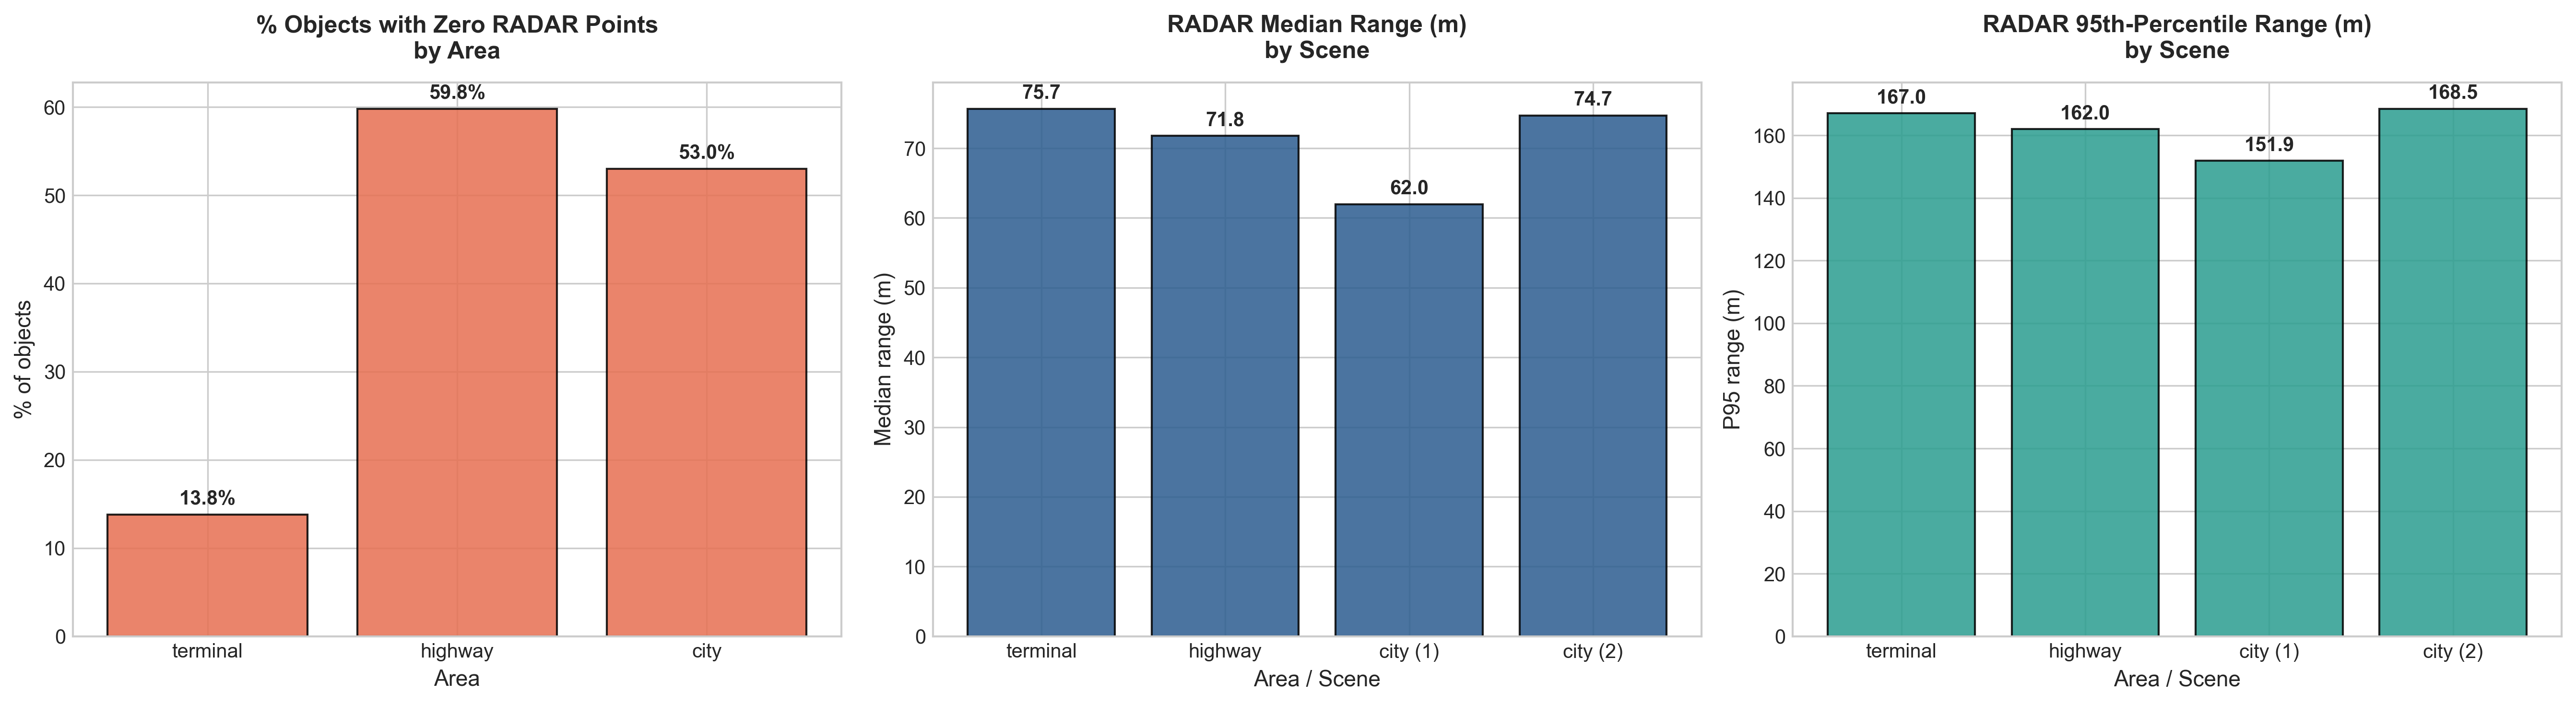

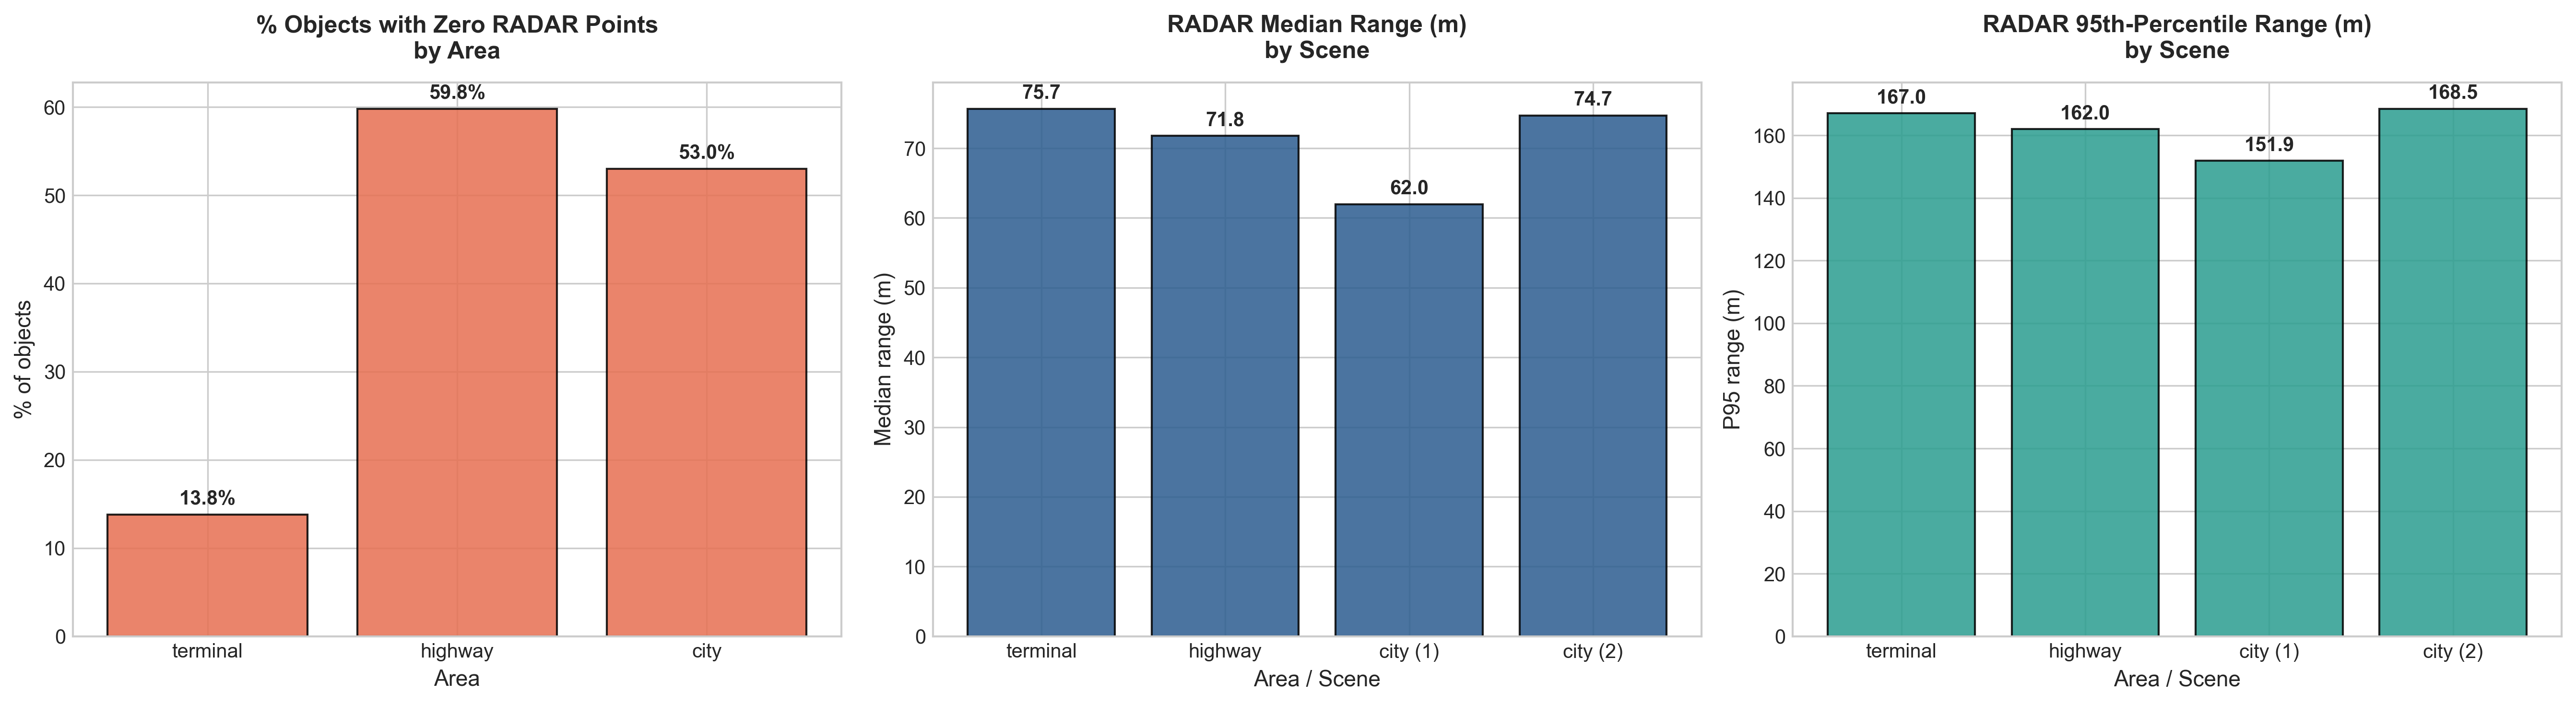

In [6]:
from plot_areas import plot_area_metrics

plot_area_metrics(zero_radar_summary, clear_scenes_full, output_fig='different_areas_radar_metrics.png')

#### Comparison against the hypothesis
The results only partly match the initial hypothesis:

- **Terminal performed best** (only 13.8% of objects undetected by RADAR), despite being cluttered with trucks, containers, and infrastructure, the opposite of what the hypothesis predicted for a structure-heavy area.
- **Highway performed worst** (59.8% undetected), despite being the "open" area expected to be easiest to detect in.
- **City sat in between** (53.0%), which does match the hypothesis direction, but the two city scenes differed substantially from each other (RADAR median: 62.0 m vs. 74.7 m) suggesting that variation within the same area label may be as large as variation between areas.

#### Limitations

Very small sample: only 4 clear-weather scenes out of 10 in the mini dataset (n=1 Terminal, n=1 Highway, n=2 City).
Area and weather are confounded in the mini dataset — clear weather only appears in these specific scenes, so results may not generalize to other weather conditions.
These results are based on the mini dataset, used here for initial/exploratory testing. The team plans to re-run this analysis on the full trainval dataset, which contains substantially more scenes — and the findings reported here (e.g. Terminal outperforming Highway) may not hold once a larger, more representative sample is used.
The data shows association, not causation — it cannot confirm why these differences occur, only that they were observed in this small sample.